# Drive Shaping Methods

A quantum program in the Rydberg analog model is defined as a time-dependent drive Hamiltonian that is imposed on the qubits (in addition to the interaction Hamiltonian). The drive shaping configuration part (the `drive_shaping` field of `SolverConfig`) defines how the drive parameters are constructed.

In this notebook, we show how to use different drive shaping methods:

- `HEURISTIC` *(Has no parameters to be customized).*
- `OPTIMIZED` *(Has seven parameters that can be customized).*

We choose the method when defining the `SolverConfig` configuration, with `drive_shaping_method = DriveType.(method)`

**Default SolverConfig parameters to run a quantum approach:**
- use_quantum: bool = False (*for using the drive shaping methods, we have to set it to `True`.*)
- backend: LocalEmulator | RemoteEmulator | QPU (by default, use a LocalEmulator based on qutip)
- device: Device = AnalogDeviceWithDMM() (also available: `AnalogDevice()`)
- embedding_method: str | EmbedderType | None = EmbedderType.GREEDY (also available: `BLADE`)
- drive_shaping_method: str | DriveType | None = DriveType.HEURISTIC (also available: `OPTIMIZED`)


In [1]:
import torch

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import SolverConfig, DriveShapingConfig
from qubosolver.qubo_types import DriveType
from qubosolver.solver import QuboSolver

import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"

%matplotlib inline

/home/ynaghmouchi/qubo-solver/.venv/lib/python3.10/site-packages/qoolqit/execution/backends.py:10: DeprecationWarning: This package is replaced by pasqal-cloud (https://pypi.org/project/pasqal-cloud/) and is going to be removed in the future.
  from pulser_pasqal.backends import EmuFreeBackendV2, RemoteEmulatorBackend


** Create the <code>QUBOInstance</code> **

Here, we have a 3x3 QUBO matrix with negative diagonal and positive off-diagonal terms.

In [2]:
coefficients = torch.tensor([[-1.0, 0.5, 0.2], [0.5, -2.0, 0.3], [0.2, 0.3, -3.0]])
instance = QUBOInstance(coefficients)

## Heuristic Drive Shaper

Default method


[HEURISTIC] num_shots=500
Solution object:
QUBOSolution(bitstrings=tensor([[0, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 0, 0, 1],
        [1, 1, 1, 0],
        [1, 1, 0, 1],
        [1, 0, 1, 1],
        [1, 1, 1, 1]], dtype=torch.int32), costs=tensor([-10.5000, -10.0000,  -9.5000,  -9.0000,  -9.0000,  -8.5000,  -8.5000,
         -4.0000]), counts=tensor([ 16,   1,  48,  16,   5,   6, 394,  14]), probabilities=tensor([0.0320, 0.0020, 0.0960, 0.0320, 0.0100, 0.0120, 0.7880, 0.0280]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)
Best sampled cost: -10.5
Best sampled bitstring: [0, 0, 1, 1]

[HEURISTIC] num_shots=500
Solution object:
QUBOSolution(bitstrings=tensor([[0, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 1],
        [1, 1, 0, 1],
        [1, 1, 1, 1]], dtype=torch.int32), costs=tensor([-10.5000, -10.0000,  -9.5000,  -9.0000,  -8.5000,  -8.5000,  -4.0000]), counts=tensor([  4,   2,   5, 

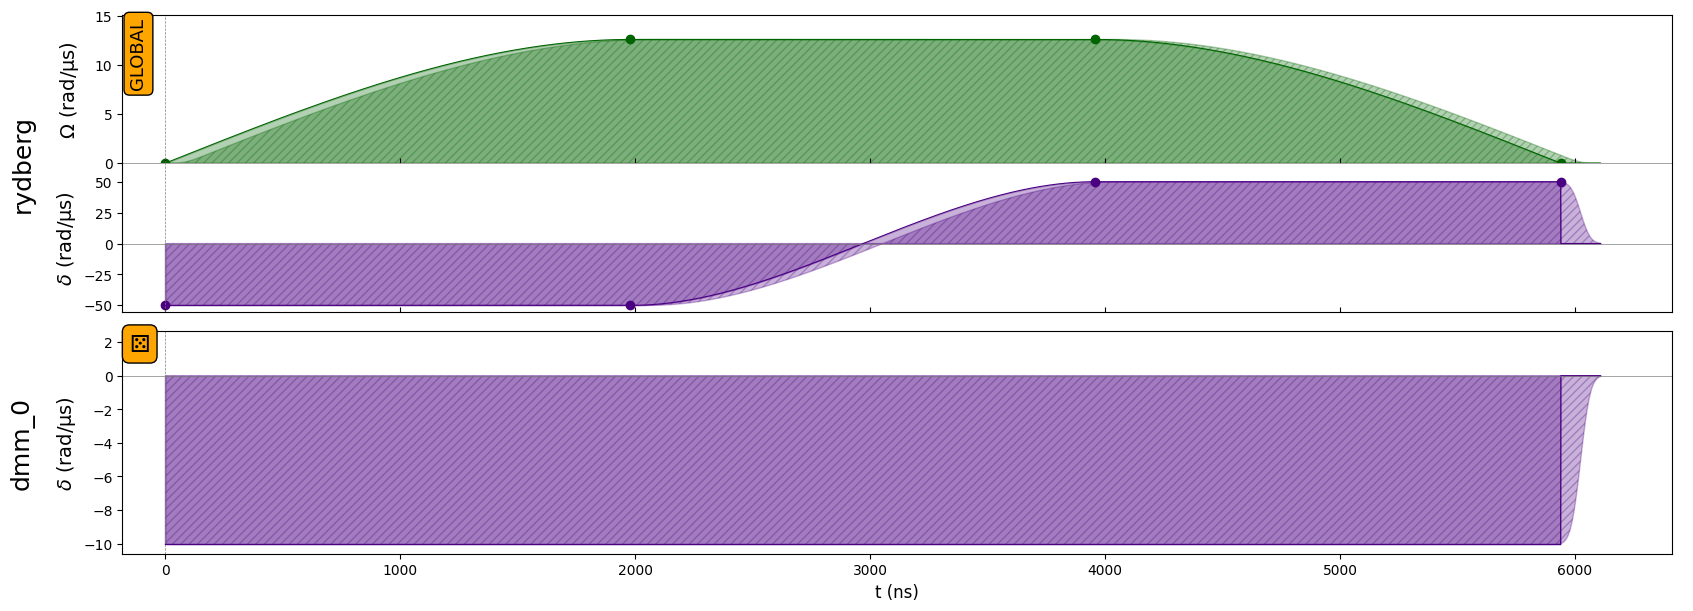

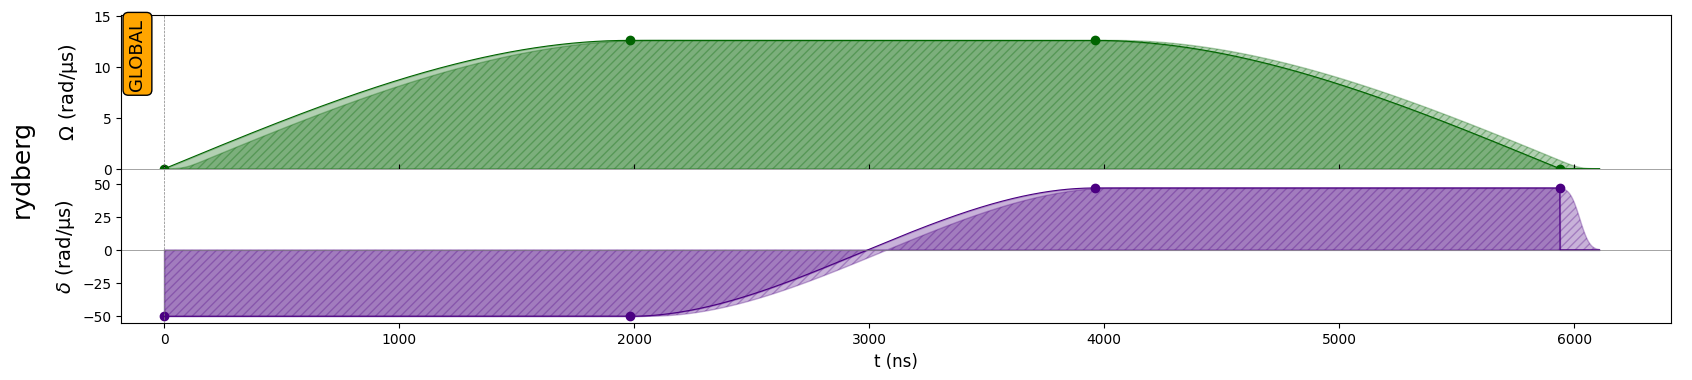

In [3]:
import torch

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import EmbeddingConfig, LocalEmulator

from pulser_simulation import QutipBackendV2


def best_from_solution(sol):
    # sol.costs: tensor([..]) ; sol.bitstrings: tensor([[..],..])
    if sol.costs is None or len(sol.costs) == 0:
        return None, None
    idx = int(torch.argmin(sol.costs).item())
    best_cost = float(sol.costs[idx].item())
    best_bitstring = sol.bitstrings[idx].tolist()
    return best_cost, best_bitstring


def run_one(method: DriveType, q: torch.Tensor, num_shots: int = 500, dmm: bool = True):
    instance = QUBOInstance(coefficients=q)

    embed_cfg = EmbeddingConfig(
        embedding_method="greedy",
        greedy_traps=6,
        # pas de greedy_spacing => default
    )

    drive_cfg = DriveShapingConfig(
        drive_shaping_method=method,
        dmm=dmm,
    )

    backend = LocalEmulator(backend_type=QutipBackendV2, num_shots=num_shots)

    config = SolverConfig(
        use_quantum=True,
        embedding=embed_cfg,
        drive_shaping=drive_cfg,
        backend=backend,
    )

    solver = QuboSolver(instance, config)

    # solve (inclut exécution + mesure)
    sol = solver.solve()

    # afficher la séquence
    embedding = solver.embedding()
    drive = solver.drive(embedding)[0]
    solver.draw_sequence(drive, embedding)

    best_cost, best_bitstring = best_from_solution(sol)

    tag = "HEURISTIC"
    print("\n" + "=" * 80)
    print(f"[{tag}] num_shots={num_shots}")
    print("Solution object:")
    print(sol)
    print(f"Best sampled cost: {best_cost}")
    print(f"Best sampled bitstring: {best_bitstring}")

    return sol, best_cost, best_bitstring


if __name__ == "__main__":
    Q1 = torch.tensor([
        [-6.0,  2.0,  2.0,  2.0],
        [ 2.0, -7.5,  2.0,  2.0],
        [ 2.0,  2.0, -7.5,  2.0],
        [ 2.0,  2.0,  2.0, -7.0],
    ])

    sol_h_dmm, best_h_dmm, bs_h_dmm = run_one(DriveType.HEURISTIC, Q1, num_shots=500, dmm=True)
    sol_h_nodmm, best_h_nodmm, bs_h_nodmm = run_one(DriveType.HEURISTIC, Q1, num_shots=500, dmm=False)

    print("\n" + "#" * 80)
    print("COMPARISON (best sampled cost):")
    print(f"HEURISTIC (dmm=True) : {best_h_dmm}  bitstring={bs_h_dmm}")
    print(f"HEURISTIC (dmm=False): {best_h_nodmm}  bitstring={bs_h_nodmm}")


[HEURISTIC] dmm=True, num_shots=1000
Best sampled cost: -21.0
Best sampled bitstring: 1000101100

[MEAN_ENERGY_HEURISTIC] dmm=True, num_shots=1000
Best sampled cost: -25.200000762939453
Best sampled bitstring: 1010100100

##############################################################################################
PROBABILITY DISTRIBUTION COMPARISON (BEST TO WORST)
##############################################################################################
Rank   Bitstring          QUBO cost      Heuristic    Mean energy     Difference
--------------------------------------------------------------------------------
1      1010100100          -25.2000         0.0000         0.0040        +0.0040
2      0001011010          -23.0000         0.0000         0.0010        +0.0010
3      0010101100          -22.6000         0.0000         0.0010        +0.0010
4      1000110100          -21.8000         0.0000         0.0010        +0.0010
5      1000101101          -21.6000         0.000

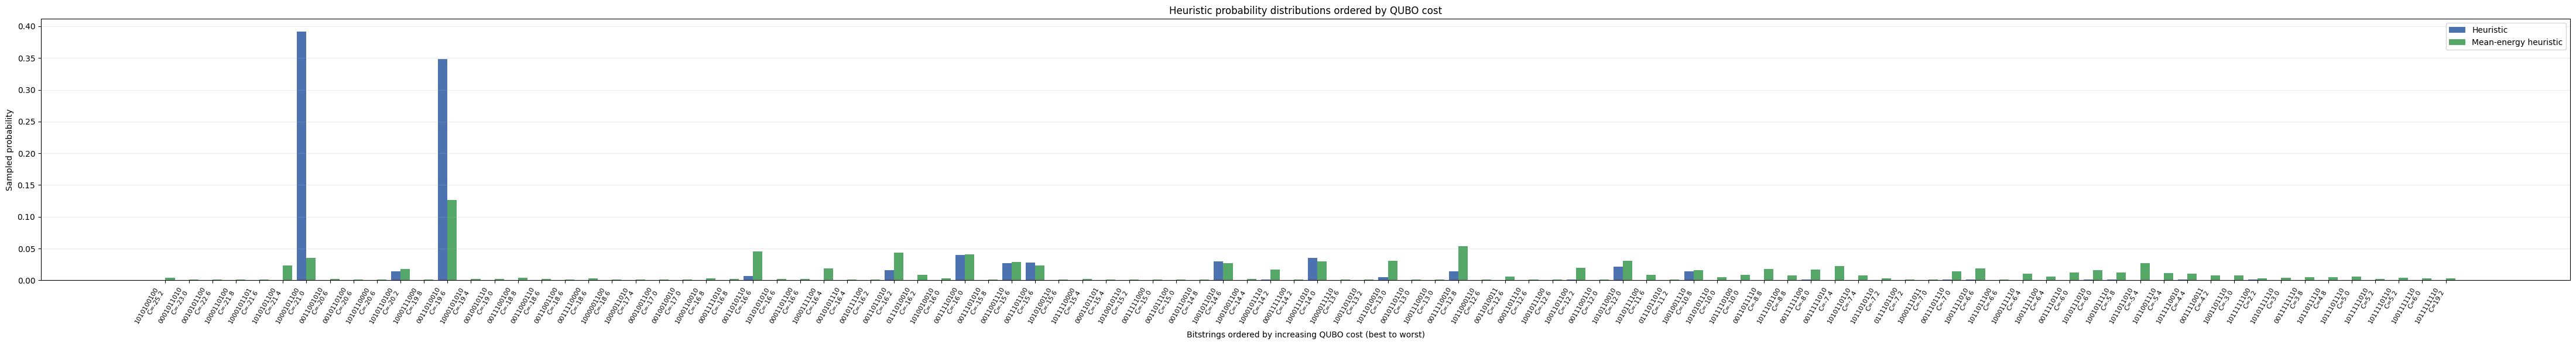

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import (
    SolverConfig,
    DriveShapingConfig,
    EmbeddingConfig,
    LocalEmulator,
)
from qubosolver.qubo_types import DriveType
from qubosolver.solver import QuboSolver

from pulser_simulation import QutipBackendV2


plt.rcParams["animation.html"] = "jshtml"
%matplotlib inline


def bitstring_to_string(bitstring) -> str:
    """Convert a tensor bitstring into a string such as '0101'."""
    if isinstance(bitstring, torch.Tensor):
        bitstring = bitstring.detach().cpu().tolist()

    return "".join(str(int(bit)) for bit in bitstring)


def extract_distribution(solution) -> dict[str, float]:
    """Extract the sampled probability distribution."""
    distribution = {}

    if solution.bitstrings is None:
        return distribution

    if (
        solution.probabilities is not None
        and len(solution.probabilities) > 0
    ):
        probabilities = solution.probabilities

    elif solution.counts is not None and len(solution.counts) > 0:
        probabilities = (
            solution.counts.float()
            / solution.counts.sum()
        )

    else:
        return distribution

    for bitstring, probability in zip(
        solution.bitstrings,
        probabilities,
    ):
        state = bitstring_to_string(bitstring)
        probability = float(probability.item())

        distribution[state] = (
            distribution.get(state, 0.0)
            + probability
        )

    return distribution


def compute_bitstring_cost(
    state: str,
    q: torch.Tensor,
) -> float:
    """Compute the original QUBO cost x.T @ Q @ x."""
    x = torch.tensor(
        [int(bit) for bit in state],
        dtype=q.dtype,
        device=q.device,
    )

    return float((x @ q @ x).item())


def best_from_solution(solution):
    """Return the best sampled cost and its bitstring."""
    if solution.costs is None or len(solution.costs) == 0:
        return None, None

    index = int(
        torch.argmin(solution.costs).item()
    )

    best_cost = float(
        solution.costs[index].item()
    )

    best_bitstring = bitstring_to_string(
        solution.bitstrings[index]
    )

    return best_cost, best_bitstring


def run_one(
    method: DriveType,
    q: torch.Tensor,
    num_shots: int = 500,
    dmm: bool = True,
):
    """Run one drive-shaping method."""
    instance = QUBOInstance(
        coefficients=q
    )

    embedding_config = EmbeddingConfig(
        embedding_method="greedy",
        greedy_traps=100,
    )

    drive_config = DriveShapingConfig(
        drive_shaping_method=method,
        dmm=dmm,
    )

    backend = LocalEmulator(
        backend_type=QutipBackendV2,
        num_shots=num_shots,
    )

    config = SolverConfig(
        use_quantum=True,
        embedding=embedding_config,
        drive_shaping=drive_config,
        backend=backend,
    )

    solver = QuboSolver(
        instance,
        config,
    )

    solution = solver.solve()

    distribution = extract_distribution(
        solution
    )

    best_cost, best_bitstring = best_from_solution(
        solution
    )

    print("\n" + "=" * 80)
    print(
        f"[{method.name}] "
        f"dmm={dmm}, "
        f"num_shots={num_shots}"
    )
    print(
        f"Best sampled cost: {best_cost}"
    )
    print(
        f"Best sampled bitstring: {best_bitstring}"
    )

    return {
        "method": method,
        "solver": solver,
        "solution": solution,
        "distribution": distribution,
        "best_cost": best_cost,
        "best_bitstring": best_bitstring,
    }


def compare_distributions(
    old_result,
    new_result,
    q: torch.Tensor,
):
    """
    Compare the two sampled distributions.

    Bitstrings are ordered by increasing QUBO cost in both
    the printed table and the figure.
    """
    old_distribution = old_result[
        "distribution"
    ]

    new_distribution = new_result[
        "distribution"
    ]

    # Keep every bitstring sampled by at least one method.
    states = list(
        set(old_distribution)
        | set(new_distribution)
    )

    # Compute the original QUBO cost of every sampled state.
    costs = {
        state: compute_bitstring_cost(
            state,
            q,
        )
        for state in states
    }

    # Minimization:
    # lowest cost = best state = first position.
    states = sorted(
        states,
        key=lambda state: (
            costs[state],
            state,
        ),
    )

    # Probabilities follow the same ordered state list.
    old_probabilities = np.array([
        old_distribution.get(state, 0.0)
        for state in states
    ])

    new_probabilities = np.array([
        new_distribution.get(state, 0.0)
        for state in states
    ])

    print("\n" + "#" * 94)
    print(
        "PROBABILITY DISTRIBUTION COMPARISON "
        "(BEST TO WORST)"
    )
    print("#" * 94)

    print(
        f"{'Rank':<7}"
        f"{'Bitstring':<14}"
        f"{'QUBO cost':>14}"
        f"{'Heuristic':>15}"
        f"{'Mean energy':>15}"
        f"{'Difference':>15}"
    )

    print("-" * 80)

    for rank, state in enumerate(
        states,
        start=1,
    ):
        old_probability = old_distribution.get(
            state,
            0.0,
        )

        new_probability = new_distribution.get(
            state,
            0.0,
        )

        difference = (
            new_probability
            - old_probability
        )

        print(
            f"{rank:<7}"
            f"{state:<14}"
            f"{costs[state]:>14.4f}"
            f"{old_probability:>15.4f}"
            f"{new_probability:>15.4f}"
            f"{difference:>+15.4f}"
        )

    # Distance between distributions.
    total_variation = (
        0.5
        * np.sum(
            np.abs(
                old_probabilities
                - new_probabilities
            )
        )
    )

    fidelity = (
        np.sum(
            np.sqrt(
                old_probabilities
                * new_probabilities
            )
        )
        ** 2
    )

    # Expected QUBO costs.
    ordered_costs = np.array([
        costs[state]
        for state in states
    ])

    old_expected_cost = np.sum(
        old_probabilities
        * ordered_costs
    )

    new_expected_cost = np.sum(
        new_probabilities
        * ordered_costs
    )

    print("\nGlobal comparison:")
    print(
        "Old heuristic best cost     : "
        f"{old_result['best_cost']}"
    )
    print(
        "New heuristic best cost     : "
        f"{new_result['best_cost']}"
    )
    print(
        "Old expected sampled cost   : "
        f"{old_expected_cost:.6f}"
    )
    print(
        "New expected sampled cost   : "
        f"{new_expected_cost:.6f}"
    )
    print(
        "Total variation distance    : "
        f"{total_variation:.6f}"
    )
    print(
        "Distribution fidelity       : "
        f"{fidelity:.6f}"
    )

    # The plot uses exactly the same ordered state list.
    x = np.arange(len(states))
    width = 0.40

    figure_width = max(
        14,
        0.45 * len(states),
    )

    fig, ax = plt.subplots(
        figsize=(figure_width, 6)
    )

    ax.bar(
        x - width / 2,
        old_probabilities,
        width,
        label="Heuristic",
        color="#4C72B0",
    )

    ax.bar(
        x + width / 2,
        new_probabilities,
        width,
        label="Mean-energy heuristic",
        color="#55A868",
    )

    ax.set_xlabel(
        "Bitstrings ordered by increasing QUBO cost "
        "(best to worst)"
    )

    ax.set_ylabel(
        "Sampled probability"
    )

    ax.set_title(
        "Heuristic probability distributions "
        "ordered by QUBO cost"
    )

    ax.set_xticks(x)

    # Show the bitstring and its cost.
    ax.set_xticklabels(
        [
            f"{state}\nC={costs[state]:.1f}"
            for state in states
        ],
        rotation=60,
        ha="right",
        fontsize=8,
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()


Q8 = torch.tensor(
    [
        [-10.0,  2.5,  1.2,  2.8,  0.9,  1.7,  2.1,  1.4,  2.6,  1.1],
        [  2.5,-10.0,  2.2,  1.1,  2.7,  1.5,  0.8,  2.4,  1.9,  2.9],
        [  1.2,  2.2,-10.0,  1.9,  1.3,  2.6,  1.6,  0.7,  2.3,  1.4],
        [  2.8,  1.1,  1.9,-10.0,  2.3,  0.6,  1.8,  2.5,  1.2,  2.0],
        [  0.9,  2.7,  1.3,  2.3,-10.0,  2.0,  1.0,  1.9,  2.8,  0.8],
        [  1.7,  1.5,  2.6,  0.6,  2.0,-10.0,  2.4,  1.2,  1.6,  2.7],
        [  2.1,  0.8,  1.6,  1.8,  1.0,  2.4,-10.0,  2.2,  0.9,  1.5],
        [  1.4,  2.4,  0.7,  2.5,  1.9,  1.2,  2.2,-10.0,  2.1,  1.3],
        [  2.6,  1.9,  2.3,  1.2,  2.8,  1.6,  0.9,  2.1,-10.0,  2.4],
        [  1.1,  2.9,  1.4,  2.0,  0.8,  2.7,  1.5,  1.3,  2.4,-10.0],
    ],
    dtype=torch.float32,
)


NUM_SHOTS = 1000
USE_DMM = True


old_result = run_one(
    DriveType.HEURISTIC,
    Q8,
    num_shots=NUM_SHOTS,
    dmm=USE_DMM,
)


new_result = run_one(
    DriveType.MEAN_ENERGY_HEURISTIC,
    Q8,
    num_shots=NUM_SHOTS,
    dmm=USE_DMM,
)


compare_distributions(
    old_result,
    new_result,
    Q8,
)

NameError: name 'solution' is not defined

## Optimized Drive shaping 

#### Parameters to customize:

For the OPTIMIZED drive shaping, we have the following parameters:
- optimized_n_calls: Number of calls for the optimization process.
- optimized_re_execute_opt_drive: Whether to re-run the optimal drive sequence after optimization.
- optimized_initial_omega_parameters: Default initial omega parameters for the drive. Defaults to (1, 2, 1).
- optimized_initial_detuning_parameters: Default initial detuning parameters for the drive. Defaults to (-2, 0, 2).

#### Default configuration

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([  7, 857,   6, 125,   5], dtype=torch.int32), probabilities=tensor([0.0070, 0.8570, 0.0060, 0.1250, 0.0050]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>optimized_n_calls</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_n_calls=13),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([177, 107, 146,  19, 551], dtype=torch.int32), probabilities=tensor([0.1770, 0.1070, 0.1460, 0.0190, 0.5510]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing the initial parameters

Initial parameters of the optimization procedure can be changed as `optimized_initial_omega_parameters` and `optimized_initial_detuning_parameters`

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_initial_omega_parameters=[0.5, 0.9, 0.5,], optimized_initial_detuning_parameters=[-0.9, 0.0, 0.5]),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-4.4000, -3.6000, -3.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([  1, 305, 349,   1, 343,   1], dtype=torch.int32), probabilities=tensor([0.0010, 0.3050, 0.3490, 0.0010, 0.3430, 0.0010]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>optimized_re_execute_opt_drive</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, optimized_re_execute_opt_drive=True),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0, 1, 1],
        [1, 0, 1],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-4.4000, -3.6000,  0.0000]), counts=tensor([  2,  18, 980]), probabilities=tensor([0.0020, 0.0180, 0.9800]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Adding custom functions

One can change the drive shaping method by incorporating custom functions for:
- Evaluating a candidate bitstring and QUBO via `optimized_custom_qubo_cost`
- Performing optimization with a different objective than the best cost via `optimized_custom_objective`
- Adding callback functions via `optimized_callback_objective`.

In [ ]:
from qubosolver.utils.qubo_eval import calculate_qubo_cost

# example of penalization
def penalized_qubo(bitstring: str, QUBO: torch.Tensor) -> float:
    return calculate_qubo_cost(bitstring, QUBO) + 2 * bitstring.count("0")

# example of saving intermediate results
opt_results = list()
def callback(d: dict) -> None:
    opt_results.append(d)

# example of using an average cost
def average_ojective(
    bitstrings: list,
    counts: list,
    probabilities: list,
    costs: list,
    best_cost: float,
    best_bitstring: str,
) -> float:
    return sum([p * c for p, c in zip(probabilities, costs)])

drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.OPTIMIZED, 
    optimized_re_execute_opt_drive=True,
    optimized_custom_qubo_cost=penalized_qubo, 
    optimized_callback_objective=callback,
    optimized_custom_objective = average_ojective,
)

config = SolverConfig(
    use_quantum=True, 
    drive_shaping=drive_shaping,
)

In [ ]:
solver = QuboSolver(instance, config)
solution = solver.solve()
len(opt_results), opt_results[-1]

(20,
 {'x': [0.8051578103612673,
   0.8368783460382281,
   0.7028792216975073,
   -0.8546360011220893,
   -0.3710044115873592,
   0.7358606666173104],
  'cost_eval': 1.003})

In [ ]:
solution

QUBOSolution(bitstrings=tensor([[0, 0, 1]], dtype=torch.int32), costs=tensor([-3.]), counts=tensor([1000]), probabilities=tensor([1.]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)